#### 18/06/25
---
---
# <center> **Pipelines**
---

## <center> **Projetos em Ciência de Dados**

#### <center> **Pós-Graduação - Instituto Mauá de Tecnologia**

#### <center> **VCP e Lucas Buk**
---
---


# **Bibliotecas**

In [ ]:
# Bibliotecas básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

seed = 1 # semente para random_state

# **Funções**

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm(model, X, y, format='.3f'):
    """Função para exibir a matriz de confusão"""

    ConfusionMatrixDisplay.from_estimator(model, X, y,
                                          values_format=format,
                                          cmap='Blues',
                                          normalize='true')
    plt.show()

# **Dados**

In [ ]:
!gdown 18lW3c0XxQoZwrwAXXRQwJReE22lMMokb --quiet

df = pd.read_csv('adult_census.csv', na_values='?')
print(df.shape)
df.head(3)

(48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


**Dados faltantes**

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
occupation,2809
workclass,2799
native-country,857
fnlwgt,0
education,0
educational-num,0
age,0
marital-status,0
relationship,0
gender,0


**Especificando um limiar para a qualidade do vinho**

In [ ]:
df.income.value_counts()

,count
income,
<=50K,37155
>50K,11687


In [ ]:
# Ajuste do Label
from sklearn.preprocessing import LabelEncoder

label_income = LabelEncoder()
df['income'] = label_income.fit_transform(df['income'])

df.head(3)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1


In [ ]:
df['income'].value_counts()

,count
income,
0,37155
1,11687


In [ ]:
# Descrição da tabela completa
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0
income,48842.0,0.239282,0.426649,0.0,0.0,0.0,0.0,1.0


**Visualização na matriz de espalhamento**

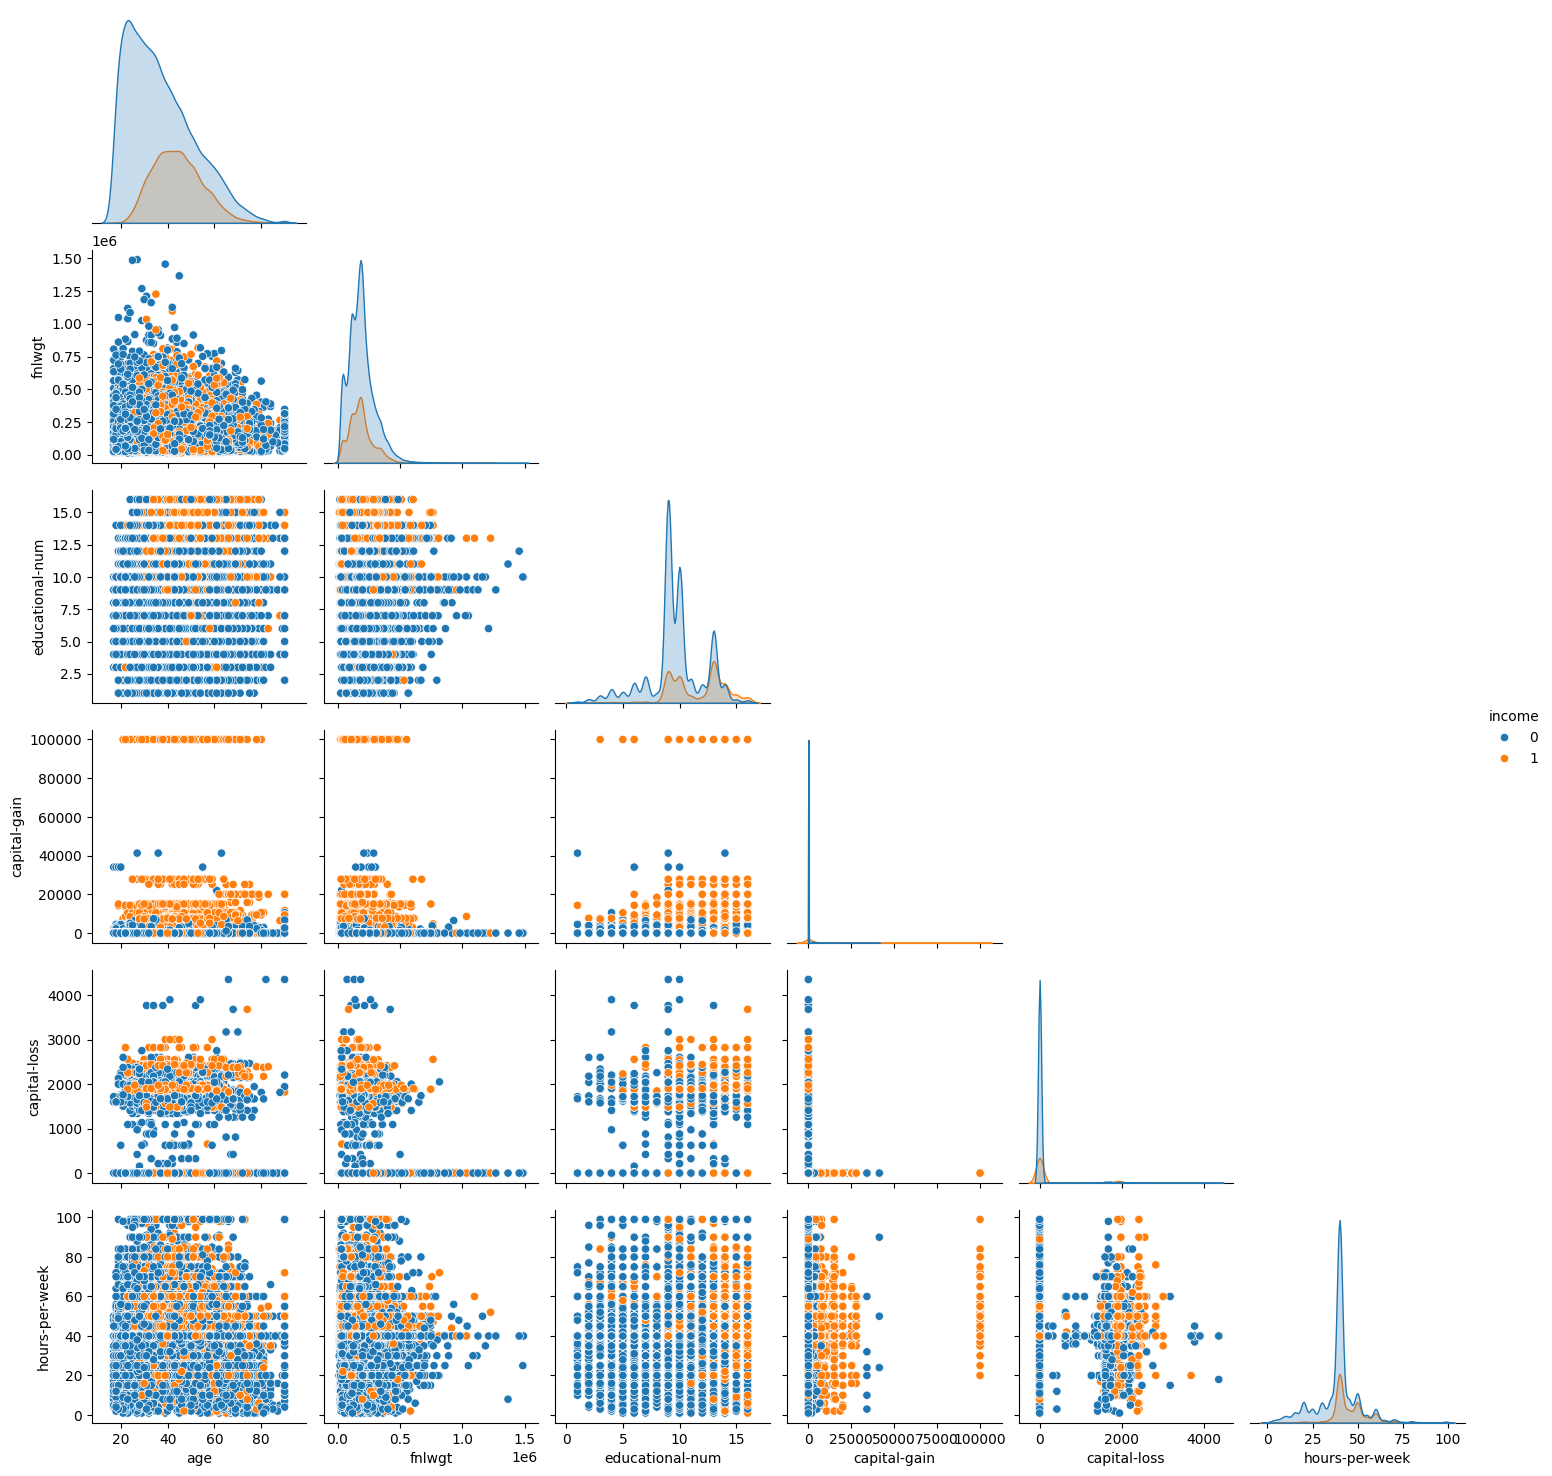

In [ ]:
# Distribuição das colunas duas a duas
sns.pairplot(df, hue='income', diag_kind='kde', corner=True)
plt.show()

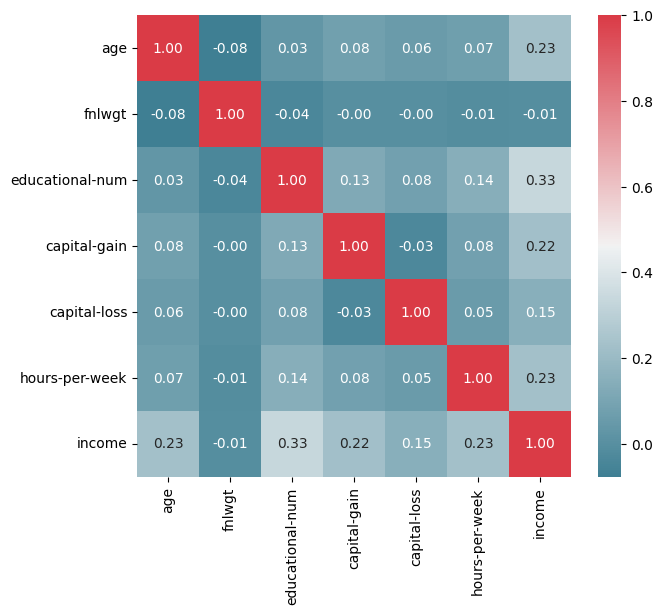

In [ ]:
# Matriz de Correlação
# Calcula a matriz de correlação entre as variáveis numéricas do DataFrame `df`
corr_matrix = df.corr(numeric_only=True)

# Cria uma nova figura do matplotlib com um eixo e define o tamanho da figura como 7 polegadas de largura por 6 polegadas de altura
fig, ax = plt.subplots(figsize=(7, 6))

# Define um mapa de cores para a matriz de calor usando o Seaborn
# A paleta de cores usada é uma divergente que vai do código de cores 220 (azul) ao código de cores 10 (vermelho)
colormap = sns.diverging_palette(220, 10, as_cmap=True)

# Plota a matriz de correlação como um mapa de calor usando Seaborn
# Os valores da matriz de correlação serão exibidos nos quadrados do mapa de calor
# Os valores serão formatados com duas casas decimais
sns.heatmap(corr_matrix, cmap=colormap, annot=True, fmt='.2f')

# Exibe a figura
fig.show()

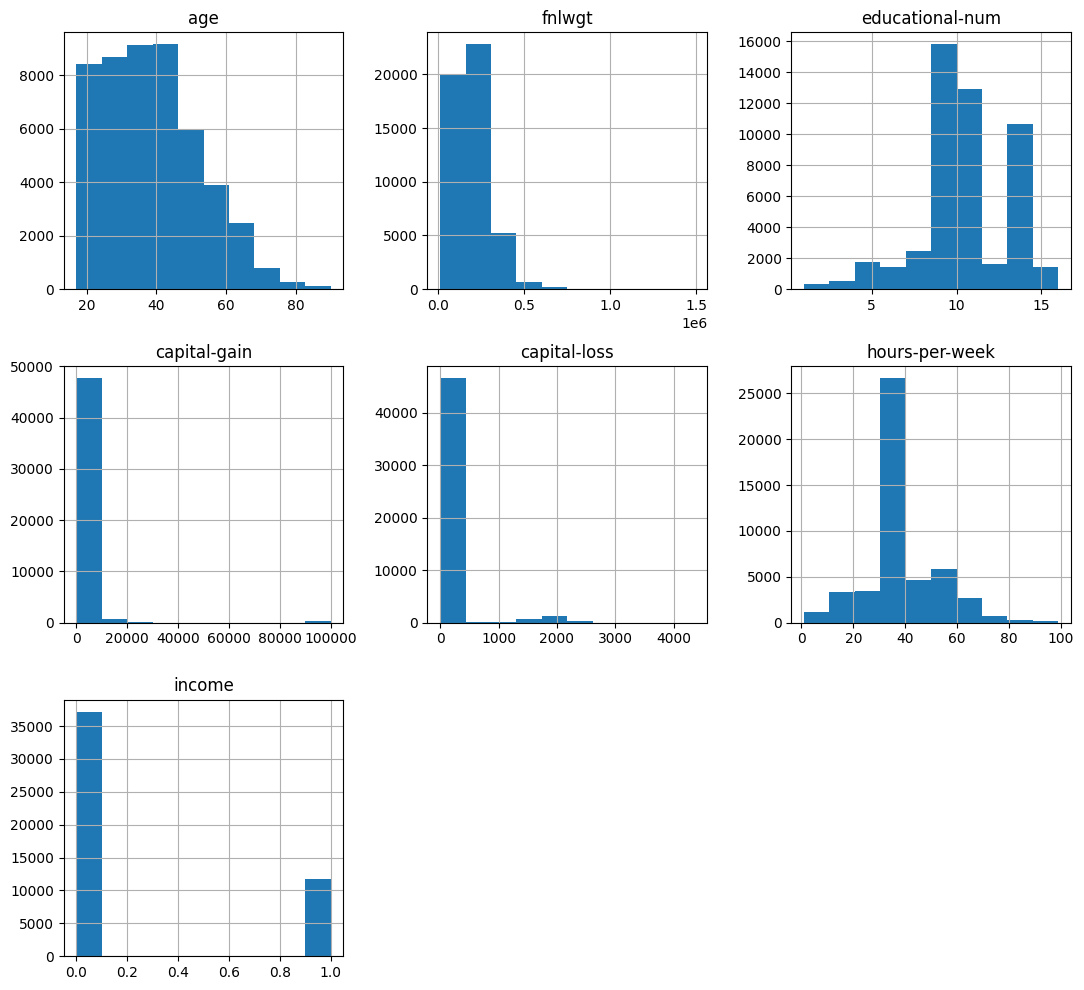

In [ ]:
# Histogramas
df.hist(bins=10, figsize=(13, 12))
plt.show()

In [ ]:
# Quantidade de colunas duplicadas
df.duplicated().sum()

np.int64(52)

In [ ]:
# Retirar as colunas duplicadas
df.drop_duplicates(keep='first', inplace=True, ignore_index=True)
df.shape

(48790, 15)

# **Pré-processamento**

In [ ]:
# Valores faltantes
df.isna().sum().sort_values(ascending=False)

**Substituição dos valores faltantes**



1.   `workclass` e `native-country` com as respectivas modas
2.   Dropna no `occupation`



In [ ]:
df.workclass.fillna(df.workclass.mode()[0], inplace=True)
df.workclass.value_counts(dropna=False)

In [ ]:
df['native-country'].fillna(df['native-country'].mode()[0], inplace=True)
df['native-country'].value_counts(dropna=False)

In [ ]:
df.dropna(inplace=True)
df.shape

**Criação de novas colunas**

**capital_change**

In [ ]:
# Não ocorre de uma pessoa ter ganho e perda de capital ao mesmo tempo
df[(df['capital-gain'] > 0) & (df['capital-loss'] > 0)].shape

In [ ]:
# Coluna única para mudança de capital
df_new = df.copy() # Como o df será alterdo, mantemos uma cópia
df_new['capital_change'] = df_new['capital-gain'] - df_new['capital-loss']

**40h_more**

In [ ]:
np.sort(df_new['hours-per-week'].unique())

In [ ]:
# Coluna indicando se a pessoa trabalha 40 horas ou mais (valor 1) ou não (valor 0)
df_new['40h_more'] = [1 if hours >= 40 else 0 for hours in df_new['hours-per-week']]
df_new['40h_more'].value_counts()

**american**

In [ ]:
# Coluna indicando de a pessoa é americana (1 = sim, 0 = não)
df_new['american'] = [1 if pais == 'United-States' else 0 for pais in df_new['native-country']]
df_new.american.value_counts()

In [ ]:
df_new.columns

**Definição das features e label**

In [ ]:
# Features e Label
cols = df_new.columns.drop(['income', 'fnlwgt', 'education',
                            'capital-gain', 'capital-loss',
                            'hours-per-week', 'native-country'])
X = df_new[cols].copy()
y = df_new.income.copy()

**Divisão em treino e teste**

In [ ]:
from sklearn.model_selection import train_test_split

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=seed,
                                                    stratify=y) # Mantém a proporção das classes

print(f'X_train = {X_train.shape}, X_test = {X_test.shape}')
print(f'y_train = {y_train.shape}, y_test = {y_test.shape}')

In [ ]:
X_train.dtypes

In [ ]:
X_train.columns

**OrdinalEncoder:**: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html

**ColumnTransformer:** https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html

**make_pipeline:** https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Colunas categóricas que serão passadas ao OneHotEncoder
# Especifica as colunas que contêm dados categóricos e que serão convertidas usando OneHotEncoder
ohe_features = ['workclass', 'relationship']

# Cria uma instância de OneHotEncoder, configurada para ignorar categorias desconhecidas
# e descartar a primeira categoria de cada coluna para evitar a multicolinearidade
ohe_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

In [ ]:
# Lista de colunas a serem codificadas pelo TargetEncoder
te_features = ['occupation']

# Cria uma instância de TargetEncoder
te_transformer = TargetEncoder(random_state=seed)

In [ ]:
# Colunas numéricas e pipeline com as transformações que serão realizadas

# Especifica as colunas que contêm dados numéricos e que serão transformadas
num_features = ['age', 'educational-num', 'marital-status', 'race', 'gender',
                'capital_change', '40h_more','american']

# Cria a instância do OrdinalEncoder
# O parâmetro 'handle_unknown' é configurado para 'use_encoded_value' com 'unknown_value'=-1 para tratar valores desconhecidos
num_transformer = OrdinalEncoder(handle_unknown='use_encoded_value',
                                 unknown_value=-1)

In [ ]:
# Combinação dos pré-processamentos

# Cria um objeto ColumnTransformer para aplicar diferentes transformações em colunas específicas do DataFrame
# O transformer 'num' aplica o num_transformer às colunas especificadas em num_features
# O transformer 'cat' aplica o ohe_transformer às colunas especificadas em ohe_features
encoder = ColumnTransformer(
    transformers=[
        ('te', te_transformer, te_features),  # Aplica o TargetEncoder
        ('cat', ohe_transformer, ohe_features),   # Aplica OneHotEncoder
        ('num', num_transformer, num_features)  # Aplica Ordinal Encoder
    ])

encoder

In [ ]:
# Cria um pipeline com os codificadores e depois com a normalização
preprocessor = make_pipeline(encoder, StandardScaler())
preprocessor

In [ ]:
# Teste com o treinamento do transformer criado
preprocessor.fit_transform(X_train, y_train)

In [ ]:
# Tamanho dos dados após a utilização do transformer
preprocessor.fit_transform(X_train, y_train).shape

# **Modelo**

In [ ]:
from xgboost import XGBClassifier

# Define os parâmetros do modelo XGBClassifier
params = {'colsample_bytree': 0.5,       # Subamostra de colunas para cada árvore
          'learning_rate': 0.1,         # Taxa de aprendizado
          'max_depth': 8,                # Profundidade máxima da árvore
          'n_estimators': 150,           # Número de árvores a serem construídas
          'random_state': seed,          # Semente para reprodutibilidade
          'scale_pos_weight': 2.6}      # Peso de escala para balancear as classes

# Cria uma instância do XGBClassifier com os parâmetros definidos
xgb = XGBClassifier()
xgb.set_params(**params)  # Define os parâmetros do modelo

# Cria um pipeline que inclui o pré-processamento (preprocessor) e o modelo (xgb)
clf = make_pipeline(preprocessor, xgb)

# Treina o pipeline com os dados de treino
clf.fit(X_train, y_train)

In [ ]:
# Matriz de confusão
plot_cm(clf, X_test, y_test)

## **Curva ROC**

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calcula as probabilidades de pertencer à classe positiva para os dados de treinamento e teste usando o modelo `clf`.
probas_train = clf.predict_proba(X_train)[:, 1]
probas_test = clf.predict_proba(X_test)[:, 1]

# Calcula a taxa de falsos positivos (FP) e a taxa de verdadeiros positivos (TP) para os dados de treinamento e teste.
fp_train, tp_train, _ = roc_curve(y_train, probas_train)
fp_test, tp_test, _ = roc_curve(y_test, probas_test)

# Cria uma figura com o tamanho especificado.
plt.figure(figsize=(10, 7))

# Plota a curva ROC para os dados de treinamento com a taxa de falsos positivos no eixo x e a taxa de verdadeiros positivos no eixo y, utilizando a cor azul.
plt.plot(fp_train, tp_train, 'b', label=f'Train (AUC = {auc(fp_train, tp_train):.3f})')

# Plota a curva ROC para os dados de teste com a taxa de falsos positivos no eixo x e a taxa de verdadeiros positivos no eixo y, utilizando a cor vermelha.
plt.plot(fp_test, tp_test, 'r', label=f'Test (AUC = {auc(fp_test, tp_test):.3f})')

# Plota a linha de base (diagonal) como referência, utilizando linha pontilhada preta.
plt.plot(np.linspace(0, 1, 100),
         np.linspace(0, 1, 100),
         label='Baseline',
         linestyle='--',
         color='k')

# Adiciona rótulos aos eixos x e y.
plt.xlabel('False Positives')
plt.ylabel('True Positives')

# Adiciona uma grade ao gráfico.
plt.grid(True)

# Adiciona uma legenda ao gráfico.
plt.legend()

# Exibe o gráfico.
plt.show()

## **Curvas de aprendizado e validação**

**Curvas de aprendizado:** http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html

In [ ]:
from sklearn.model_selection import learning_curve

# Calcula os dados da curva de aprendizado para diversos tamanhos de treinamento
train_sizes, train_scores, test_scores = learning_curve(estimator=clf,  # Estimador (pipeline) a ser usado
                                                        X=X_train,      # Dados de treino
                                                        y=y_train,      # Rótulos de treino
                                                        train_sizes=np.linspace(0.1, 1.0, 5),  # Proporções do tamanho do conjunto de treinamento
                                                        cv=5,          # Número de folds na validação cruzada
                                                        shuffle=True,   # Mistura os dados antes de dividir em folds
                                                        random_state=seed)  # Semente para reprodutibilidade

# Calcula a média e o desvio padrão das acurácias nos dados de treino e teste
train_mean = np.mean(train_scores, axis=1)  # Média das acurácias de treino
train_std = np.std(train_scores, axis=1)    # Desvio padrão das acurácias de treino
test_mean = np.mean(test_scores, axis=1)    # Média das acurácias de teste
test_std = np.std(test_scores, axis=1)      # Desvio padrão das acurácias de teste

# Visualização das curvas de aprendizado
plt.figure(figsize=(10, 8))

# Plota a média da acurácia de treino
plt.plot(train_sizes, train_mean, color='blue', marker='o',
         markersize=5, label='Acurácia treino')

# Preenche a área ao redor da curva de treino para indicar a variação (desvio padrão)
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std,
                 alpha=0.15, color='blue')

# Plota a média da acurácia de teste
plt.plot(train_sizes, test_mean, color='green', linestyle='--',
         marker='s', markersize=5, label='Acurácia teste')

# Preenche a área ao redor da curva de teste para indicar a variação (desvio padrão)
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std,
                 alpha=0.15, color='green')

# Configurações adicionais do gráfico
plt.grid()  # Adiciona uma grade ao gráfico
plt.xlabel('Número de exemplos treinados')  # Rótulo do eixo x
plt.ylabel('Acurácia')  # Rótulo do eixo y
plt.legend()  # Exibe a legenda
plt.show()  # Mostra o gráfico

**Curvas de validação:** http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html

In [ ]:
clf.get_params()

In [ ]:
from sklearn.model_selection import validation_curve

# Define os valores do hiperparâmetro 'max_depth' que serão investigados
param_range = [3, 4, 5, 6, 7, 8, 9, 10]

# Calcula a curva de validação para diferentes valores do hiperparâmetro 'max_depth'
train_scores, test_scores = validation_curve(estimator=clf,  # Estimador (pipeline) a ser usado
                                             X=X_train,      # Dados de treino
                                             y=y_train,      # Rótulos de treino
                                             param_name='xgbclassifier__max_depth',  # Nome do hiperparâmetro a ser ajustado (usando pipeline)
                                             param_range=param_range,  # Intervalo de valores para o hiperparâmetro
                                             cv=5)  # Número de folds na validação cruzada

# Calcula a média e o desvio padrão das acurácias nos dados de treino e teste
train_mean = np.mean(train_scores, axis=1)  # Média das acurácias de treino
train_std = np.std(train_scores, axis=1)    # Desvio padrão das acurácias de treino
test_mean = np.mean(test_scores, axis=1)    # Média das acurácias de teste
test_std = np.std(test_scores, axis=1)      # Desvio padrão das acurácias de teste

# Visualização das curvas de validação
plt.figure(figsize=(10, 8))

# Plota a média da acurácia de treino para cada valor de 'max_depth'
plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='Acurácia treino')

# Preenche a área ao redor da curva de treino para indicar a variação (desvio padrão)
plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

# Plota a média da acurácia de teste para cada valor de 'max_depth'
plt.plot(param_range, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Acurácia teste')

# Preenche a área ao redor da curva de teste para indicar a variação (desvio padrão)
plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

# Configurações adicionais do gráfico
plt.grid()  # Adiciona uma grade ao gráfico
plt.legend()  # Exibe a legenda
plt.xlabel('Parâmetro max_depth')  # Rótulo do eixo x
plt.ylabel('Acurácia')  # Rótulo do eixo y
plt.show()  # Mostra o gráfico

# **Referências**

**Pipelines:** https://subscription.packtpub.com/book/data/9781789955750/6/ch06lvl1sec36/streamlining-workflows-with-pipelines

https://medium.com/data-hackers/introdu%C3%A7%C3%A3o-a-pipelines-do-scikit-learn-c5f4f1c2c1f2